In [6]:
from langgraph.graph import START,END,StateGraph,MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain.messages import RemoveMessage

In [2]:
load_dotenv()

True

In [3]:
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [4]:
def chat_node(state:MessagesState):
    response=llm.invoke(state["messages"])
    return {"messages":[response]}

In [26]:
def delete_old_messages(state:MessagesState):

    msgs=state["messages"]

    if len(msgs)>10:
        to_remove=msgs[:6]
        return {"messages":[RemoveMessage(id=m.id) for m in to_remove]}
    
    return {}

In [27]:
graph=StateGraph(MessagesState)
graph.add_node("chat",chat_node)
graph.add_node("delete",delete_old_messages)
graph.add_edge(START,"chat")
graph.add_edge("chat","delete")
graph.add_edge("delete",END)
checkpointer=InMemorySaver()

chatbot=graph.compile(checkpointer=checkpointer)

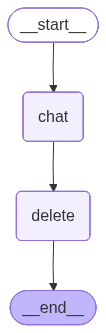

In [28]:
chatbot

In [9]:
config = {"configurable": {"thread_id": "t1"}}

In [29]:
# Run multiple turns
chatbot.invoke({"messages": [{"role": "user", "content": "Hi"}]}, config)
chatbot.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
chatbot.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)
chatbot.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)
chatbot.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics"}]}, config)
chatbot.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)
chatbot.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

{'messages': [HumanMessage(content='What is Langchain', additional_kwargs={}, response_metadata={}, id='93734c48-9b77-40e7-8a6a-b139042c06f1'),
  AIMessage(content="LangChain is an open-source framework for building and deploying large language models (LLMs) like LangGraph. It's designed to simplify the process of developing, training, and deploying LLMs, and provides a flexible and modular architecture for integrating LLMs with other AI and machine learning components.\n\n**Key Features of LangChain:**\n\n1. **Modular architecture**: LangChain provides a modular architecture that allows developers to easily integrate LLMs with other AI and machine learning components, such as computer vision, speech recognition, and natural language processing (NLP) models.\n2. **LLM integration**: LangChain provides pre-built integrations with popular LLMs like LangGraph, allowing developers to easily deploy and manage LLMs in their applications.\n3. **Training and fine-tuning**: LangChain provides t

In [30]:
snap = chatbot.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))

Stored messages after cleanup: 8


In [14]:
print(snap)

StateSnapshot(values={'messages': [HumanMessage(content='What is Langchain', additional_kwargs={}, response_metadata={}, id='d62f0346-fce1-40ba-b923-df825c32c7b3'), AIMessage(content='LangChain is an open-source framework developed by Harrison Chase and other researchers, designed to facilitate the creation of applications that utilize large language models (LLMs) like LangGraph. LangChain provides a set of tools, libraries, and APIs that simplify the process of building, deploying, and managing LLM-based applications.\n\n**Key Features of LangChain**\n\n1. **Modular Architecture**: LangChain is built using a modular architecture, allowing developers to easily integrate different LLMs, agents, and tools into their applications.\n2. **Agent-Based Framework**: LangChain introduces the concept of "agents," which are modular components that encapsulate specific functionality, such as text generation, summarization, or conversation management.\n3. **LLM Integration**: LangChain provides pre

In [32]:
chatbot.invoke({"messages":[{"role":"user","content":"hi my name is sunjosh"}]},config=config)

{'messages': [HumanMessage(content='What is my name', additional_kwargs={}, response_metadata={}, id='f8a4e494-5346-459c-9db0-51303ee6e420'),
  AIMessage(content="I don't know your name. I'm a large language model, I don't have the ability to know or recall personal information about individuals, including their names. Each time you interact with me, it's a new conversation and I don't retain any information from previous conversations. If you'd like to share your name with me, I'd be happy to chat with you and use it in our conversation!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 83, 'prompt_tokens': 2338, 'total_tokens': 2421, 'completion_time': 0.200190859, 'completion_tokens_details': None, 'prompt_time': 0.269092968, 'prompt_tokens_details': None, 'queue_time': 0.320883679, 'total_time': 0.469283827}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_d42c28f9ce', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs':

In [34]:
chatbot.invoke({"messages":[{"role":"user","content":"what is the current playing 11 of rcb"}]},config=config)

{'messages': [HumanMessage(content='What is my name', additional_kwargs={}, response_metadata={}, id='f8a4e494-5346-459c-9db0-51303ee6e420'),
  AIMessage(content="I don't know your name. I'm a large language model, I don't have the ability to know or recall personal information about individuals, including their names. Each time you interact with me, it's a new conversation and I don't retain any information from previous conversations. If you'd like to share your name with me, I'd be happy to chat with you and use it in our conversation!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 83, 'prompt_tokens': 2338, 'total_tokens': 2421, 'completion_time': 0.200190859, 'completion_tokens_details': None, 'prompt_time': 0.269092968, 'prompt_tokens_details': None, 'queue_time': 0.320883679, 'total_time': 0.469283827}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_d42c28f9ce', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs':

In [35]:
snap = chatbot.get_state(config)
print(len(snap.values["messages"]))

8


In [23]:
snap.values["messages"][-1].content

"I don't have any information about your name. If you'd like to share it with me, I can use it to address you in our conversation. Otherwise, I'll continue to use neutral language to communicate with you. How can I assist you today?"

In [24]:
chatbot.invoke({"role":"user","content":"what is the full form of rcb"},config=config)

{'messages': [HumanMessage(content='What is my name', additional_kwargs={}, response_metadata={}, id='04f51212-7173-4a56-83ed-fb70771430c4'),
  AIMessage(content='I don\'t know your name. I\'m a large language model, I don\'t have the ability to know or recall personal information about individuals, including their names. Each time you interact with me, it\'s a new conversation and I don\'t retain any information from previous conversations.\n\nIf you\'d like to share your name with me, I\'d be happy to use it to address you in our conversation. Otherwise, I\'ll continue to refer to you as "user" or use other neutral language to communicate with you.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 105, 'prompt_tokens': 2322, 'total_tokens': 2427, 'completion_time': 0.258320886, 'completion_tokens_details': None, 'prompt_time': 0.210508901, 'prompt_tokens_details': None, 'queue_time': 0.327312693, 'total_time': 0.468829787}, 'model_name': 'llama-3.3-70b-v

In [25]:
snap.values["messages"][-1].content

"I don't have any information about your name. If you'd like to share it with me, I can use it to address you in our conversation. Otherwise, I'll continue to use neutral language to communicate with you. How can I assist you today?"